## 회귀 심화 사전 과제

### 회귀 기초 복습

> 회귀란?  

- 연속적인 데이터에서 패턴을 찾아내는 통계적 방법
- 선형회귀, 비선형회귀, 릿지회귀, 라쏘회귀, 다항회귀
- 데이터 요약, 예측, 시계열 모델링 및 변수 간 인과관계 발견
- MSE, MAE, R-square, Adjusted R-squre, AIC, BC(SC) 지표로 평가  
  
머신러닝  
- 지도학습: 정답으로 간주할 데이터 존재
- 비지도학습: 정답으로 간주할 데이터 없음
  
> 단순/다중 선형회귀분석  

- 설명변수 개수의 차이 있을뿐, 두 회귀 분석은 본질 적으로 같음
- 단순: 하나의 독립변수
- 다중: 두 개 이상의 독립변수
  
> 최소제곱법  

- OLS(최소자승법)이라고 함
- 잔차=회귀선 - 관측값
- 잔차 제곱의 합(RSS or SSR)을 최소화하는 회귀선 찾음
  
> 회귀 분석 프로세스  

1. 사전 검증: 데이터 탐색 및 전처리, 기본 가정 6가지 검토
2. 모델 생성 및 모델 fit: 회귀 모델 생성, 모델 설정, 모델 학습, 유의성 검정
3. 모델 성능 평가: R-squared, 회귀 분석 후 검증 가능한 가설 검토
4. 모델 성능 개선: 필요 없는 변수 제거, 비선형 모델 활용

### 선형회귀

> 다중선형회귀의 수식적 이해  

$$ y_i=\beta_0+\beta_1X_{1i}+\beta_2X_{2i}+...+\beta_kX_{ki}+\varepsilon_i $$
  
- 종속변수 y에 대한 독립변수들의 가중평균
- 설명변수에 가중치를 곱해 더함으로써 y를 얼마나 잘 설명하는지 나타냄
- **but 모든 상황에 선형회귀 쓸 수 있는 것 아님!!**
  
> 다중선형회귀의 기본 가정 6가지  

**가정1 - 선형성**
- 종속변수와 설명변수 간 관계가 선형적이어야 함
  
**가정2 - 독립성**
- 각각의 설명변수가 서로 선형독립적이어야 함
- 선형독립적이지 않은 경우 => 다중공선성이 있다고 함
- 다중공선성: 독립변수들이 서로 강한 상관관계 가짐 -> 어떤 변수가 종속 변수에 가장 큰 영향을 주는지 알 수 없음
  
**가정3 - 오차항의 평균은 0**
- 오차항: 실제값과 예측값 사이의 차이
- 백색 잡음: 특정 패턴 없이 랜덤하게 변하는 신호 -> 이 성질을 만족하기 위해 오차항 평균 0이어야 함
- 만족하지 않을 경우, 회귀 모델이 항상 잘못 예측하니까 데이터 패턴 올바르게 예측하지 못한 것
  
**가정4 - 등분산성**
- 오차항의 분산이 일정해야 함
- 이분산성: 오차항의 분산이 일정하지 않음
    - 이 경우 회귀 분석의 결과가 정확하지 않을 수 있음
    - 모델의 예측이 일부 구간에서는 매우 정확하지만 일부 구간에선는 오차가 큼
- 잔차를 도표화하거나 Brown-Forsythe, Breusch-Pagan 검정을 통해 등분산성 알아볼 수 있음
  
**가정5 - 오차항은 자기상관되어 있지 않음**
- 오차항의 공분산(Cov)는 항상 0
- 공분산: 두 변수 간 상관된 정보를 나타내는 지표
- 오차항의 공분산이 0이 아닌 경우, 자기상관이 있다고 함
    - *오차는 순수하게 랜덤해야 한다!!*
    - 자기상관: 한 변수의 현재 값이 과거 값과 상관관계를 가지는 현상
    - 시계열 자료에서 많이 나타남
    - 모델이 데이터를 랜덤하게 예측하는 것이 아니라, 이전 데이터의 패턴을 학습하여 반복적인 오류를 만들어낼 가능성 높음
- 더빈-왓슨 검정, ACF, PACF 함수로 확인 가능
  
**가정6(선택) - 정규성**
- 오차항이 정규분포를 따름
    - p-value 계산에 필요한 가정
- 선택사항
- 샤피로-윌크 검정, 자퀴-베라 검정, Q-Q plot 등으로 확인
  
회귀 분석 전에 검증: 선형성, 독립성, 오차항 자기 상관 없음  
회귀 분석 후에 검증: 전부  
  
- 기준: 오차항에 대한 가정인가?
    - 오차항은 모델 학습 후에 정해지므로 모델 학습 전에 파악 불가
  
> 회귀분석 평가 방법  

1. 시각화
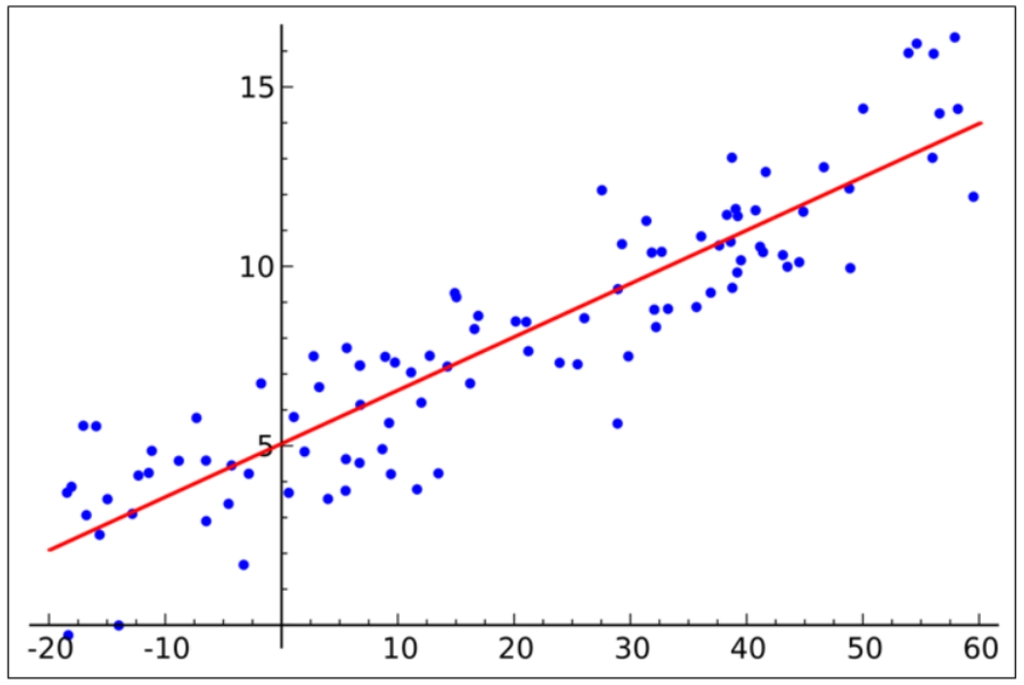  
  
- 전반적으로 파악 가능하지만 정확히 비교하기 위해서는 통계지표를 활용해야 함
  
2. 통계지표
    1. 모델 유의성 검정
    - F-statistic, Prob(F-statistic): *회귀 모델*이 유의미한지 검정하는 지표, 값이 클수록 모델이 통계적으로 유의미하다고 판단, Prob 0.05 기준
    - T-statistic, Prob(T-statistic): *각 독립변수*가 종속변수 y에 유의미한 영향을 미치는지 판단하는 지표, p-value를 기준으로 검정 수행
      
    2. 모델의 성능 평가
    - 결정 계수(R-squared): 회귀 모델이 종속 변수의 전체 변동성을 얼마나 잘 설명하는지 나타내는 지표, 모델이 데이터를 얼마나 잘 설명하는지, 1에 가까울수록 설명 잘했다는 뜻
    - 조정된 결정 계수(Adjusted R-squared): R squred의 경우 독립 변수의 개수 증가하면 자연스럽게 증가, 이에 덜 민감하도록 조정한 지표
    - AIC(Akaike information criterion): 복잡성에 대한 패널티 작음, 값 낮을수록 좋다고 평가
    - BIC(SC): AIC보다 엄격한 기준, 데이터에 양에 더 강한 패널티 부과, 값 낮을수록 좋다고 평가

### 비선형 회귀
  
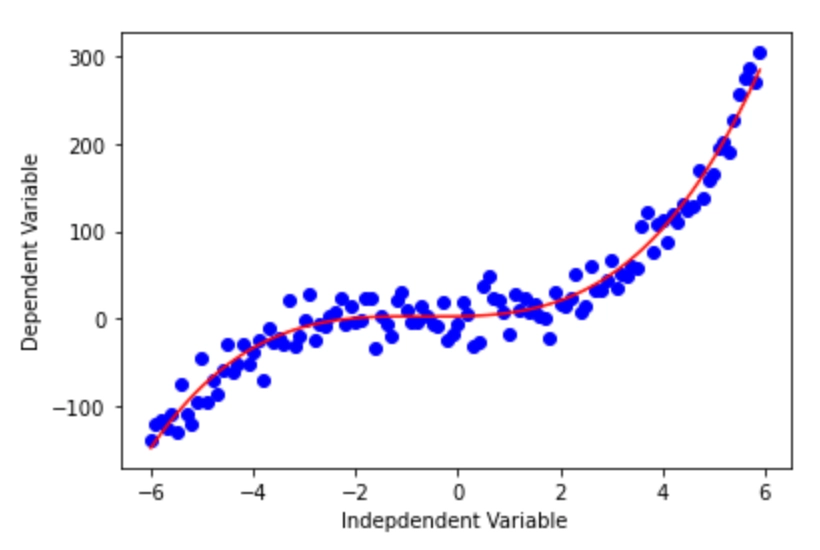
  
이미지와 같이 선형적이지 않은 경우  

> 다항식 회귀 모델  

- 기존의 선형 회귀: $Y=a+bX$
- 다항식 회귀 모델: $Y=a+bX+cX^2+...$의 형태로 독립 변수에 거듭제곱 항을 추가하여 데이터의 곡선적 특성을 모델링
- 장점: 선형모델에 비해 회귀선을 데이터에 fit하게 그릴 수 있음
- 단점: 너무 많은 독립변수 이용하면 결과 overfitting 될 수 있음
- 적합한 상황
    - 관계가 직선적이지 않고 곡선을 그리는 데이터 패턴
    - 성장률, 감소율 등이 시간에 따라 변화하는 속도가 다른 경우
  
> 지수 회귀 모델  

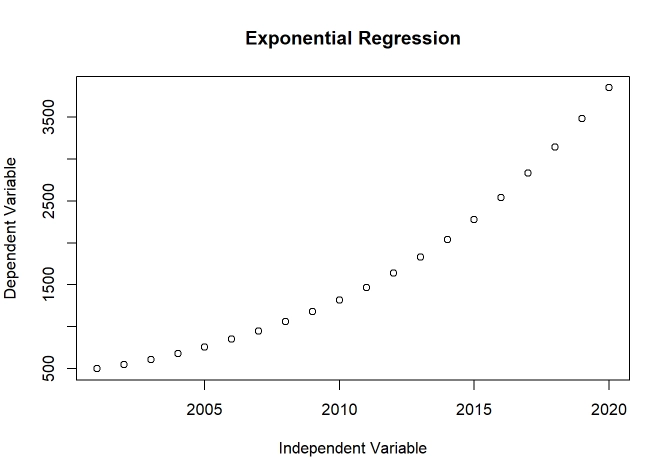
  
- 종속변수가 지수적으로 변화하는 관계를 모델링
- 종속변수 Y에 로그를 취한 후 선형회귀 적용 -> 예측 값에 지수함수를 적용
- 적합한 상황
    - 값이 시간에 따라 지수적으로 증가하거나 감소하는 경우
    - 기술 발전, 투자 수익률 증가 등
  
> 로그 회귀 모델  

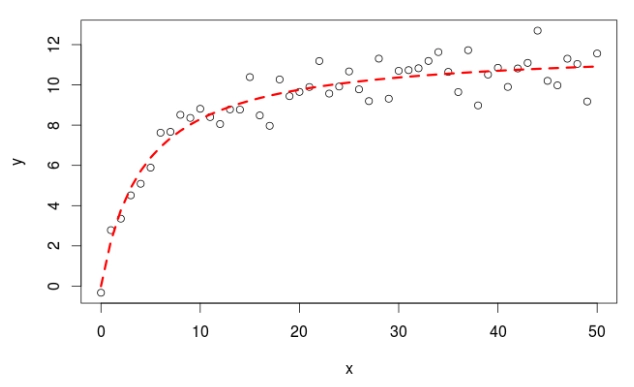
  
- 종속 변수와 독립 변수 간 관계가 로그 함수를 통해 더 잘 표현될 때 사용
- 독립변수 X에 로그 연산 취한 후 선형회귀 적용
- 적합한 상황
    - 데이터가 초기에 빠르게 증가하고 점차 증가율이 줄어드는 패턴을 보일 때 효과적
    - 인구 성장, 감염병 확산과 같이 초기 빠른 증가 후 점진적 감소를 보이는 데이터에 적합
  
> 스플라인 회귀  

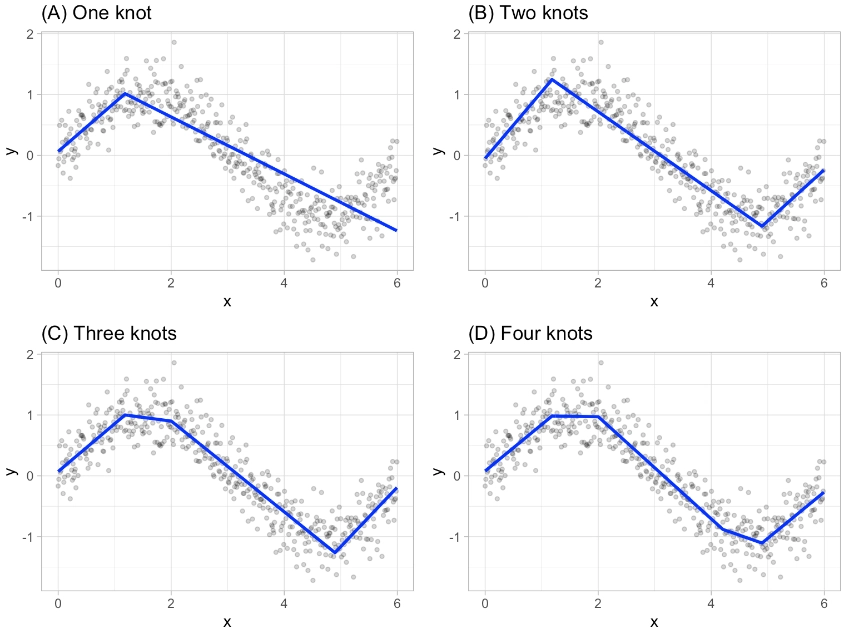
  
- 데이터를 구간별로 나누고 각 구간에서 다른 선형 또는 비선형 함수를 적용하여 예측하는 방식
- 전체 데이터 범위를 여러 구간으로 나누고 각 구간에 대해 별도의 회귀모델을 적용
- 구간 경계에서의 연속성 유지
- 적합한 상황
    - 데이터 패턴이 여러 구간에서 서로 다르게 나타날 때
    - 계절에 따라 판매량이 변화하는 소매 데이터 분석 등